# Pré-processamento de Dados e Baseline

In [30]:
# Realizando os imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [9]:
# Carregando o dataset itub4_processed.csv
df = pd.read_csv("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/itub4_processed.csv", index_col="Date", parse_dates=True)

In [10]:
FEATURES = ["Open", "High", "Low", "Close", "Volume", "EMA_60"]
TARGET = "Close"
WINDOW_SIZE = 50
TRAIN_RATIO = 0.80

### Tratamento de valores ausentes

In [ ]:
# Preços ausentes (NaN): interpolação linear preserva a continuidade da série
price_cols = ["Open", "High", "Low", "Close", "EMA_60"]
df[price_cols] = df[price_cols].interpolate(method="linear", limit_direction="both")

# Volume zerado: substituir pelo último valor válido (forward fill)
df["Volume"] = df["Volume"].replace(0, np.nan)
df["Volume"] = df["Volume"].fillna(0)

# Verificação final — não deve sobrar nenhum NaN
assert df.isnull().sum().sum() == 0, "Ainda há valores ausentes após tratamento!"
print("Tratamento de ausentes concluído. Nenhum NaN restante.")
print(df.shape)

Tratamento de ausentes concluído. Nenhum NaN restante.
(1247, 6)


### Divisão de treino e teste

In [14]:
n = len(df)
train_size = int(n * TRAIN_RATIO)

df_train = df.iloc[:train_size]
df_test  = df.iloc[train_size:]

print(f"Total: {n} dias")
print(f"Treino: {len(df_train)} dias  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Teste:  {len(df_test)}  dias  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Total: 1247 dias
Treino: 997 dias  (2021-05-03 → 2025-04-30)
Teste:  250  dias  (2025-05-02 → 2026-04-30)


### Normalização Z-score por feature

In [17]:
scalers = {}
df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()

for col in FEATURES:
    scaler = StandardScaler()
    # Fit apenas no treino
    df_train_scaled[col] = scaler.fit_transform(df_train[[col]])
    # Transform no teste com os parâmetros do treino
    df_test_scaled[col]  = scaler.transform(df_test[[col]])

    scalers[col] = scaler
    joblib.dump(scaler, f"/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/scalers/scaler_{col.lower()}.pkl")
    print(f"  {col}: µ={scaler.mean_[0]:.4f}, σ={scaler.scale_[0]:.4f}")

print("\nScalers serializados em models/scalers/")

  Open: µ=20.5881, σ=4.0966
  High: µ=20.8141, σ=4.1095
  Low: µ=20.3715, σ=4.0995
  Close: µ=20.5936, σ=4.1091
  Volume: µ=35088447.4935, σ=16759050.5632
  EMA_60: µ=20.2958, σ=3.7275

Scalers serializados em models/scalers/


In [ ]:
print("=== Treino ===")
print(df_train_scaled.describe().loc[["mean", "std"]].round(4))

print("\n=== Teste ===")
print(df_test_scaled.describe().loc[["mean", "std"]].round(4))

=== Treino (deve ter µ≈0, σ≈1) ===
       Close    High     Low    Open  Volume  EMA_60
mean  0.0000  0.0000 -0.0000 -0.0000 -0.0000  0.0000
std   1.0005  1.0005  1.0005  1.0005  1.0005  1.0005

=== Teste (µ e σ podem diferir ligeiramente) ===
       Close    High     Low    Open  Volume  EMA_60
mean  4.0947  4.1286  4.0693  4.1076 -0.6558  4.0965
std   1.2168  1.2412  1.1941  1.2236  0.5859  1.2058


### Definição de janela temporal

In [ ]:
def create_windows(data: pd.DataFrame, window_size: int, target_col: str):
    """
    Retorna X com shape (n_samples, window_size, n_features)
    e y com shape (n_samples,) contendo o valor de fechamento do dia seguinte.
    """
    X, y = [], []
    values = data.values
    target_idx = data.columns.get_loc(target_col)

    for i in range(window_size, len(data)):
        X.append(values[i - window_size : i, :])   # janela de 50 dias
        y.append(values[i, target_idx])             # fechamento do dia seguinte

    return np.array(X), np.array(y)


X_train, y_train = create_windows(df_train_scaled, WINDOW_SIZE, TARGET)
X_test,  y_test  = create_windows(df_test_scaled,  WINDOW_SIZE, TARGET)

print(f"X_train: {X_train.shape}  →  (amostras, janela, features)")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (947, 50, 6)  →  (amostras, janela, features)
y_train: (947,)
X_test:  (200, 50, 6)
y_test:  (200,)


In [20]:
df_processed = pd.concat([df_train_scaled, df_test_scaled])
df_processed.to_csv("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/database/processed/ITUB4_processed.csv", index=True)
print(f"Dataset processado salvo: data/processed/ITUB4_processed.csv ({len(df_processed)} linhas)")

Dataset processado salvo: data/processed/ITUB4_processed.csv (1247 linhas)


## Implementação de Modelo de Persistência

In [21]:
# Carrega o scaler de Close (fit apenas no treino — sem data leakage)
scaler_close = joblib.load("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/scalers/scaler_close.pkl")

# Desnormaliza y_test para comparação em R$ (conforme padrão da Etapa 1, seção 3.7)
y_test_real = scaler_close.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --- Baseline no espaço normalizado ---
y_pred_baseline_norm = np.roll(y_test, shift=1)
y_pred_baseline_norm[0] = y_test[0]

# --- Desnormalização ---
y_pred_baseline_real = scaler_close.inverse_transform(
    y_pred_baseline_norm.reshape(-1, 1)
).flatten()

print(f"y_pred_baseline_real — min: R${y_pred_baseline_real.min():.2f} | max: R${y_pred_baseline_real.max():.2f}")
print(f"Amostras no conjunto de teste: {len(y_test_real)}")

y_pred_baseline_real — min: R$30.97 | max: R$48.93
Amostras no conjunto de teste: 200


In [22]:
np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/y_pred_baseline.npy", y_pred_baseline_real)
np.save("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/y_test_real.npy",     y_test_real)

print("Arrays serializados em models/baseline/")

Arrays serializados em models/baseline/


### Recuperação do índice temporal do conjunto de teste

In [23]:
n = len(df_processed)
train_size = int(n * TRAIN_RATIO)

# As primeiras WINDOW_SIZE linhas do split de teste são consumidas pela janela
# A primeira previsão corresponde ao índice train_size + WINDOW_SIZE
test_dates = df_processed.index[train_size + WINDOW_SIZE:]

assert len(test_dates) == len(y_test_real), (
    f"Incompatibilidade de tamanhos: datas={len(test_dates)}, y_test={len(y_test_real)}"
)

print(f"Período de teste: {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Total de pregões no teste: {len(test_dates)}")

Período de teste: 2025-07-14 → 2026-04-30
Total de pregões no teste: 200


### Gráfico: Preço real vs Baseline

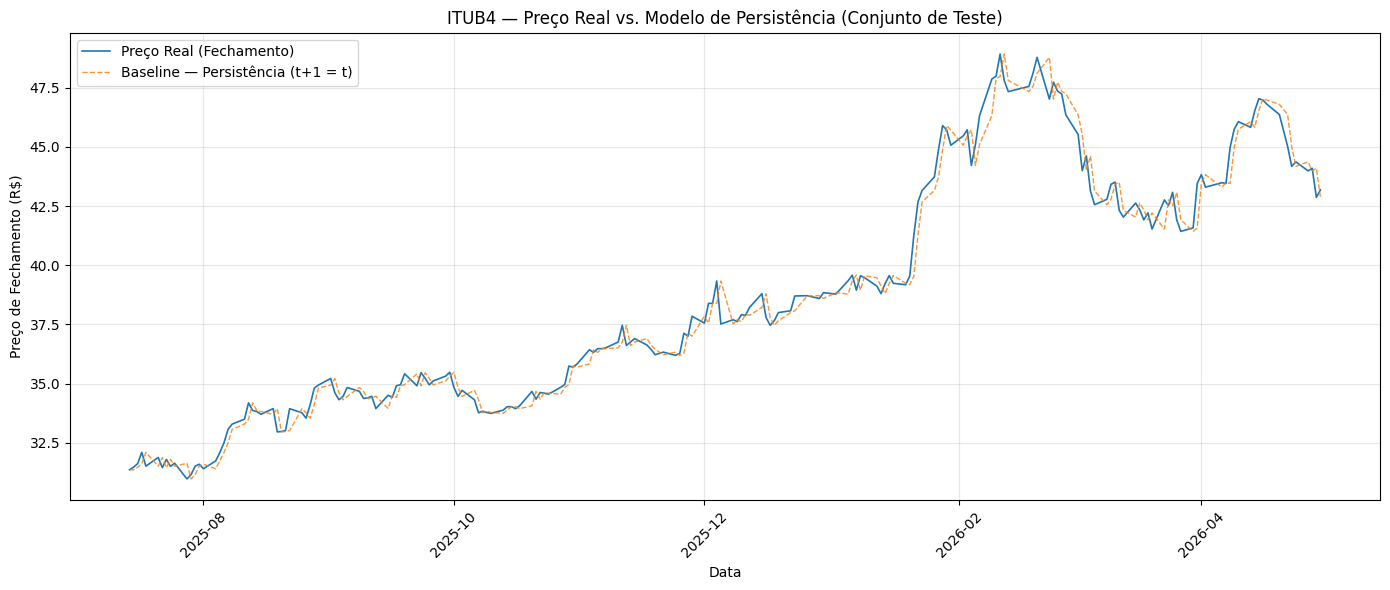

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test_real,        color="#1f77b4", linewidth=1.2,
        label="Preço Real (Fechamento)")
ax.plot(test_dates, y_pred_baseline_real, color="#ff7f0e", linewidth=1.0,
        linestyle="--", alpha=0.85, label="Baseline — Persistência (t+1 = t)")

ax.set_title("ITUB4 — Preço Real vs. Modelo de Persistência (Conjunto de Teste)")
ax.set_ylabel("Preço de Fechamento (R$)")
ax.set_xlabel("Data")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
#plt.savefig("data/figures/06_baseline_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()

## Avaliação de Baseline

### Cálculo de Métricas

In [32]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Exclui pontos onde y_true == 0 para evitar divisão por zero
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


baseline_rmse = rmse(y_test_real, y_pred_baseline_real)
baseline_mae  = mae(y_test_real,  y_pred_baseline_real)
baseline_mape = mape(y_test_real, y_pred_baseline_real)

print("=== Métricas do Baseline (Persistência) ===")
print(f"  RMSE : R$ {baseline_rmse:.4f}")
print(f"  MAE  : R$ {baseline_mae:.4f}")
print(f"  MAPE :    {baseline_mape:.4f} %")

=== Métricas do Baseline (Persistência) ===
  RMSE : R$ 0.5995
  MAE  : R$ 0.4447
  MAPE :    1.1196 %


### Serialização das métricas

In [33]:
import json

metrics = {
    "model":      "persistence_baseline",
    "split":      "test",
    "n_samples":  int(len(y_test_real)),
    "RMSE":       round(baseline_rmse, 6),
    "MAE":        round(baseline_mae,  6),
    "MAPE":       round(baseline_mape, 6),
}

with open("/Users/lucaszaninidasilva/Mackenzie/SetimoSemestre/IA/PROJETO/src/models/baseline/baseline_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Métricas salvas em models/baseline/baseline_metrics.json")
print(json.dumps(metrics, indent=2))

Métricas salvas em models/baseline/baseline_metrics.json
{
  "model": "persistence_baseline",
  "split": "test",
  "n_samples": 200,
  "RMSE": 0.59952,
  "MAE": 0.444745,
  "MAPE": 1.119607
}


### Gráfico de resíduos de baseline

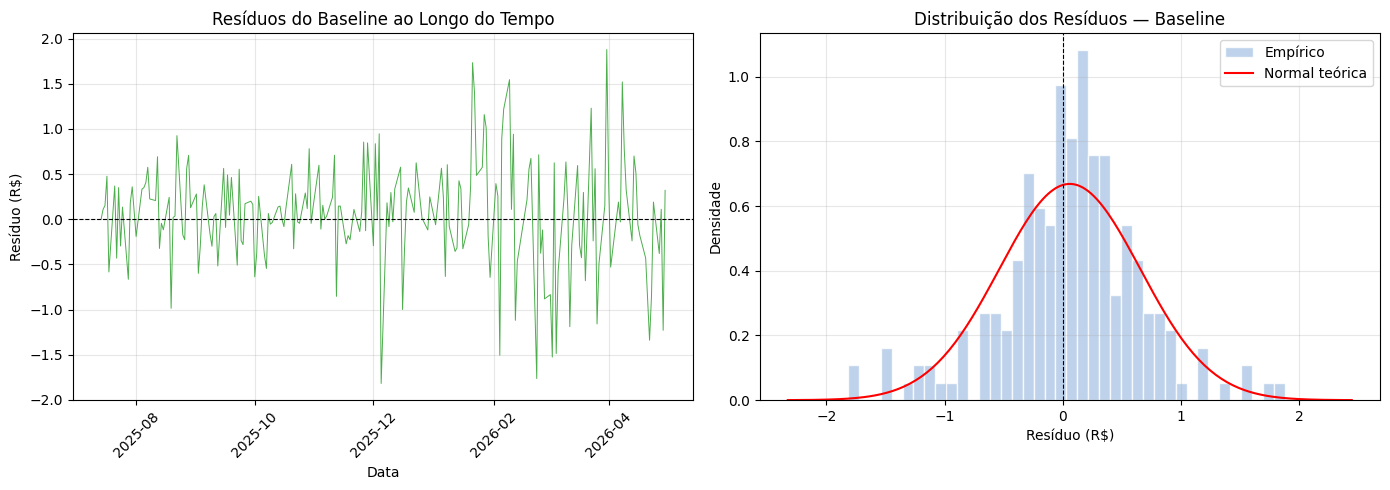

Resíduos — µ: 0.0592 | σ: 0.5966
Curtose: 1.2858


In [36]:
from scipy.stats import norm

residuos = y_test_real - y_pred_baseline_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Série temporal dos resíduos ---
axes[0].plot(test_dates, residuos, color="#2ca02c", linewidth=0.7, alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Resíduos do Baseline ao Longo do Tempo")
axes[0].set_ylabel("Resíduo (R$)")
axes[0].set_xlabel("Data")
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].get_xticklabels(), rotation=45)

# --- Histograma dos resíduos com curva normal ---
mu_res, sigma_res = residuos.mean(), residuos.std()
x_res = np.linspace(mu_res - 4 * sigma_res, mu_res + 4 * sigma_res, 200)

axes[1].hist(residuos, bins=40, density=True,
             color="#aec7e8", edgecolor="white", alpha=0.8, label="Empírico")
axes[1].plot(x_res, norm.pdf(x_res, mu_res, sigma_res),
             "r-", linewidth=1.5, label="Normal teórica")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Distribuição dos Resíduos — Baseline")
axes[1].set_xlabel("Resíduo (R$)")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("data/figures/07_baseline_residuos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Resíduos — µ: {mu_res:.4f} | σ: {sigma_res:.4f}")
print(f"Curtose: {pd.Series(residuos).kurt():.4f}")

In [38]:
print("\n========================================")
print("  Resumo: Baseline de Persistência")
print("========================================")
print(f"  Período de teste : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"  Amostras         : {len(y_test_real)}")
print(f"  RMSE             : R$ {baseline_rmse:.4f}")
print(f"  MAE              : R$ {baseline_mae:.4f}")
print(f"  MAPE             : {baseline_mape:.4f} %")
print("========================================\n")
print("Estes valores são o piso mínimo que a LSTM deverá superar na Fase 3.")


  Resumo: Baseline de Persistência
  Período de teste : 2025-07-14 → 2026-04-30
  Amostras         : 200
  RMSE             : R$ 0.5995
  MAE              : R$ 0.4447
  MAPE             : 1.1196 %

Estes valores são o piso mínimo que a LSTM deverá superar na Fase 3.
